# ANOM EDA — 이상탐지 알고리즘 설계 (GCS 데이터)

**목적**: StatisticalAnomalyDetector(ANOM-001) · PatternAnomalyDetector(ANOM-002) 임계값 검증  
**데이터**: GCS `ax-nilm-data-dhwang0803-us` (원천데이터 + 라벨)  
**구간 전략**: 전체 31일 → 앞 3주(베이스라인) / 마지막 1주(평가)

## 0. 환경 설정

In [1]:
!pip install -q gcsfs pyarrow pandas numpy matplotlib seaborn scikit-learn
!apt-get -qq install fonts-nanum
!rm -rf ~/.cache/matplotlib   # 폰트 캐시 초기화

import matplotlib as mpl
import matplotlib.font_manager as fm

# 직접 파일 경로로 등록 (캐시 재시작 없이 적용)
NANUM_PATH = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(NANUM_PATH)
mpl.rcParams['font.family'] = fm.FontProperties(fname=NANUM_PATH).get_name()
mpl.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지
print(f'한글 폰트 적용: {mpl.rcParams["font.family"]}')

Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
한글 폰트 적용: ['NanumGothic']


In [3]:
from google.colab import auth
auth.authenticate_user()
print('GCP 인증 완료')

GCP 인증 완료


In [4]:
import gcsfs
gcs = gcsfs.GCSFileSystem()
print('GCS 연결 완료')

GCS 연결 완료


In [5]:
import os, sys

REPO_DIR = '/content/ax_nilm'
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/dhwang0803-glitch/ax_nilm {REPO_DIR} -q
    print('클론 완료')
else:
    !git -C {REPO_DIR} pull -q && echo '최신화 완료'

SRC_DIR = f'{REPO_DIR}/nilm-engine/src'
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

ANOMALY_SRC = f'{REPO_DIR}/anomaly-detection'
if ANOMALY_SRC not in sys.path:
    sys.path.insert(0, ANOMALY_SRC)

print('경로 설정 완료')

클론 완료
경로 설정 완료


In [6]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')
RESULTS_DIR = Path('/content/drive/MyDrive/nilm_anomaly_eda')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'결과 저장 → {RESULTS_DIR}')

Mounted at /content/drive
결과 저장 → /content/drive/MyDrive/nilm_anomaly_eda


In [7]:
# ── 분석 대상 가구 설정 ──────────────────────────────────────────────
HOUSE = 'house_049'   # ← 여기만 바꾸면 다른 가구 분석 가능

BUCKET_PREFIX = 'ax-nilm-data-dhwang0803-us/nilm/training_dev10'
LABEL_PATH    = 'ax-nilm-data-dhwang0803-us/nilm/labels/training.parquet'

# ── 분석할 가전 (None이면 전체 로드) ──────────────────────────────────
# 채널이 많을 때는 패턴 유형별 대표 가전만 선택해 메모리·시간 절약
TARGET_APPLIANCES = {
    '일반 냉장고',      # 연속 부하 — 소비량 기준선
    '세탁기',           # 주기적 고전력 — 작동시간 이상
    '에어컨',           # 계절성 고전력 — 피크 이상
    '전기밥솥',         # 일상 패턴 — 시간대 주기성
    '전자레인지',       # 단발 고전력 — 패턴 이상
    'TV',               # 저전력 일상 — 주기성 변화
}
# TARGET_APPLIANCES = None  # ← 전체 로드 시 이 줄로 교체

print(f'분석 대상: {HOUSE}')
print(f'선택 가전: {TARGET_APPLIANCES if TARGET_APPLIANCES else "전체"}')

분석 대상: house_049
선택 가전: {'일반 냉장고', '전기밥솥', '전자레인지', '세탁기', 'TV', '에어컨'}


In [8]:
import warnings
warnings.filterwarnings('ignore')

import gc
from datetime import timedelta, datetime, date as date_cls
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from dataclasses import dataclass, field
from enum import Enum
import uuid

from acquisition.gcs_loader import (
    list_channels_gcs,
    load_channel_data_gcs,
    get_appliance_name_gcs,
    get_house_start_date_gcs,
)

plt.rcParams['figure.figsize'] = (14, 4)
sns.set_style('whitegrid')
print('imports OK')

imports OK


## 1. 가전별 데이터 로딩 (GCS)

In [9]:
# 가구의 채널 목록 조회
channels = list_channels_gcs(gcs, HOUSE, bucket_prefix=BUCKET_PREFIX)
print(f'{HOUSE} 채널: {channels}')

# 채널 → 가전명 매핑 (라벨 없는 채널은 채널 ID로 fallback)
ch_to_appliance = {}
for ch in channels:
    name = get_appliance_name_gcs(gcs, HOUSE, ch, label_path=LABEL_PATH)
    if name and not pd.isna(name):
        ch_to_appliance[ch] = str(name)
    else:
        ch_to_appliance[ch] = ch   # 라벨 없으면 "ch02" 등 채널 ID 사용

print('채널 → 가전명:')
for ch, name in ch_to_appliance.items():
    print(f'  {ch}: {name}')

house_049 채널: ['ch01', 'ch02', 'ch03', 'ch04', 'ch05', 'ch06', 'ch07', 'ch08', 'ch09', 'ch11', 'ch12', 'ch13', 'ch14', 'ch16', 'ch17', 'ch18', 'ch19', 'ch21', 'ch22']
채널 → 가전명:
  ch01: 메인 분전반
  ch02: TV
  ch03: 선풍기
  ch04: 전기포트
  ch05: 전기밥솥
  ch06: 세탁기
  ch07: 헤어드라이기
  ch08: 진공 청소기(유선)
  ch09: 전자레인지
  ch11: 의류건조기
  ch12: 식기세척기
  ch13: 에어컨
  ch14: 전기장판, 담요
  ch16: 인덕션(전기레인지)
  ch17: 컴퓨터
  ch18: 전기다리미
  ch19: 공기청정기
  ch21: 일반 냉장고
  ch22: 김치 냉장고


In [10]:
AGGREGATE_KEYWORDS = {'메인', '분전반', '집계', 'main', 'aggregate'}
RESAMPLE_FREQ = '1min'
CHUNK_DAYS = 7   # 7일씩 청킹 → 채널당 피크 ~200MB

appliance_series: dict[str, pd.Series] = {}
POWER_COL = None

for ch, appliance in ch_to_appliance.items():
    # 집계 채널 스킵
    if any(kw in appliance for kw in AGGREGATE_KEYWORDS):
        print(f'  SKIP {appliance} ({ch}) — 집계 채널')
        continue

    # TARGET_APPLIANCES 필터 (None이면 전체 로드)
    if TARGET_APPLIANCES and appliance not in TARGET_APPLIANCES:
        continue

    # 데이터 시작일 조회
    try:
        start_date = get_house_start_date_gcs(gcs, HOUSE, ch, bucket_prefix=BUCKET_PREFIX)
    except FileNotFoundError:
        print(f'  SKIP {ch} — GCS 경로 없음')
        continue

    end_date = start_date + timedelta(days=30)

    # 7일 청크 단위로 로드 → 즉시 리샘플 → 원본 해제
    chunks = []
    current = start_date
    while current <= end_date:
        chunk_end = min(current + timedelta(days=CHUNK_DAYS - 1), end_date)
        try:
            raw = load_channel_data_gcs(
                gcs, HOUSE, ch,
                date_range=(str(current), str(chunk_end)),
                bucket_prefix=BUCKET_PREFIX,
            )
            raw = raw.set_index('date_time').sort_index()

            if POWER_COL is None:
                for candidate in ['agg_power', 'power_w', 'power', 'value', 'watt']:
                    if candidate in raw.columns:
                        POWER_COL = candidate
                        break
                if POWER_COL is None:
                    POWER_COL = raw.select_dtypes(include='number').columns[0]
                print(f'  전력 컬럼: {POWER_COL}')

            chunks.append(raw[POWER_COL].resample(RESAMPLE_FREQ).mean())
            del raw
            gc.collect()
        except Exception as e:
            print(f'  {ch} {current}~{chunk_end} 오류: {e}')
        current = chunk_end + timedelta(days=1)

    if chunks:
        s = pd.concat(chunks)
        appliance_series[appliance] = s
        print(f'  {appliance} ({ch}): {len(s):,}행  {s.index.min().date()} ~ {s.index.max().date()}')

    del chunks
    gc.collect()

APPLIANCES = list(appliance_series.keys())
print(f'\n총 {len(APPLIANCES)}종 가전 로드 완료: {APPLIANCES}')

  SKIP 메인 분전반 (ch01) — 집계 채널
  전력 컬럼: active_power
  TV (ch02): 44,640행  2023-10-12 ~ 2023-11-11
  전기밥솥 (ch05): 44,640행  2023-10-12 ~ 2023-11-11
  세탁기 (ch06): 44,640행  2023-10-12 ~ 2023-11-11
  전자레인지 (ch09): 44,640행  2023-10-12 ~ 2023-11-11
  에어컨 (ch13): 44,640행  2023-10-12 ~ 2023-11-11
  일반 냉장고 (ch21): 44,640행  2023-10-12 ~ 2023-11-11

총 6종 가전 로드 완료: ['TV', '전기밥솥', '세탁기', '전자레인지', '에어컨', '일반 냉장고']


In [11]:
print(f'전력 컬럼: {POWER_COL}')
print(f'리샘플 주기: {RESAMPLE_FREQ}')
print(f'가전 수: {len(APPLIANCES)}')

# 샘플 확인
sample_s = next(iter(appliance_series.values()))
print(f'\n샘플 ({APPLIANCES[0]}):')
print(sample_s.head(5))

전력 컬럼: active_power
리샘플 주기: 1min
가전 수: 6

샘플 (TV):
date_time
2023-10-12 00:00:00    0.463300
2023-10-12 00:01:00    0.459356
2023-10-12 00:02:00    0.461894
2023-10-12 00:03:00    0.462228
2023-10-12 00:04:00    0.462439
Freq: min, Name: active_power, dtype: float32


In [12]:
# 가전별 1분 Series → wide DataFrame (EDA/시각화용은 1H로 추가 리샘플)
wide_1min = pd.DataFrame(appliance_series)

# 시각화·분석용 1시간 평균
wide = wide_1min.resample('1H').mean()

print(f'1분 DataFrame: {wide_1min.shape}')
print(f'1시간 DataFrame: {wide.shape}  ({wide.index.min().date()} ~ {wide.index.max().date()})')
print(f'총 기간: {(wide.index.max() - wide.index.min()).days}일')
wide.head(3)

1분 DataFrame: (44640, 6)
1시간 DataFrame: (744, 6)  (2023-10-12 ~ 2023-11-11)
총 기간: 30일


,TV,전기밥솥,세탁기,전자레인지,에어컨,일반 냉장고
date_time,,,,,,
2023-10-12 00:00:00,0.465521,2.306650,0.463558,1.060273,6.360854,61.429420
2023-10-12 01:00:00,0.466324,2.323277,0.467538,1.072345,6.381275,50.263771
2023-10-12 02:00:00,0.467516,2.325270,0.467695,1.075698,6.380478,67.724991


## 2. 기본 EDA

In [13]:
print('=== 결측치 ===')
print(wide.isnull().sum())
print('\n=== 기술통계 (W) ===')
wide.describe().round(1)

=== 결측치 ===
TV        0
전기밥솥      0
세탁기       0
전자레인지     0
에어컨       0
일반 냉장고    0
dtype: int64

=== 기술통계 (W) ===


,TV,전기밥솥,세탁기,전자레인지,에어컨,일반 냉장고
count,744.0,744.0,744.0,744.0,744.0,744.0
mean,36.4,7.7,31.2,3.4,6.7,47.9
std,49.7,28.4,84.2,10.7,2.5,16.1
min,0.4,2.2,0.4,1.0,6.1,0.0
25%,0.5,2.2,0.4,1.0,6.2,39.0
50%,0.5,2.3,0.5,1.0,6.2,44.6
75%,101.2,2.3,0.5,1.1,6.3,51.2
max,141.4,286.2,492.4,104.0,23.7,145.7


## 3. 시계열 시각화

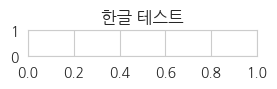

imports OK  |  폰트: ['NanumGothic']


In [18]:
import warnings
warnings.filterwarnings('ignore')

import gc
from datetime import timedelta, datetime, date as date_cls
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.ensemble import IsolationForest
from dataclasses import dataclass, field
from enum import Enum
import uuid

from acquisition.gcs_loader import (
    list_channels_gcs,
    load_channel_data_gcs,
    get_appliance_name_gcs,
    get_house_start_date_gcs,
)

# seaborn 스타일 먼저 적용 후 한글 폰트 덮어쓰기
sns.set_style('whitegrid')

NANUM_PATH = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(NANUM_PATH)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (14, 4)

# 적용 확인
test_fig, test_ax = plt.subplots(figsize=(3, 1))
test_ax.set_title('한글 테스트')
plt.tight_layout()
plt.show()
plt.close()
print('imports OK  |  폰트:', plt.rcParams['font.family'])

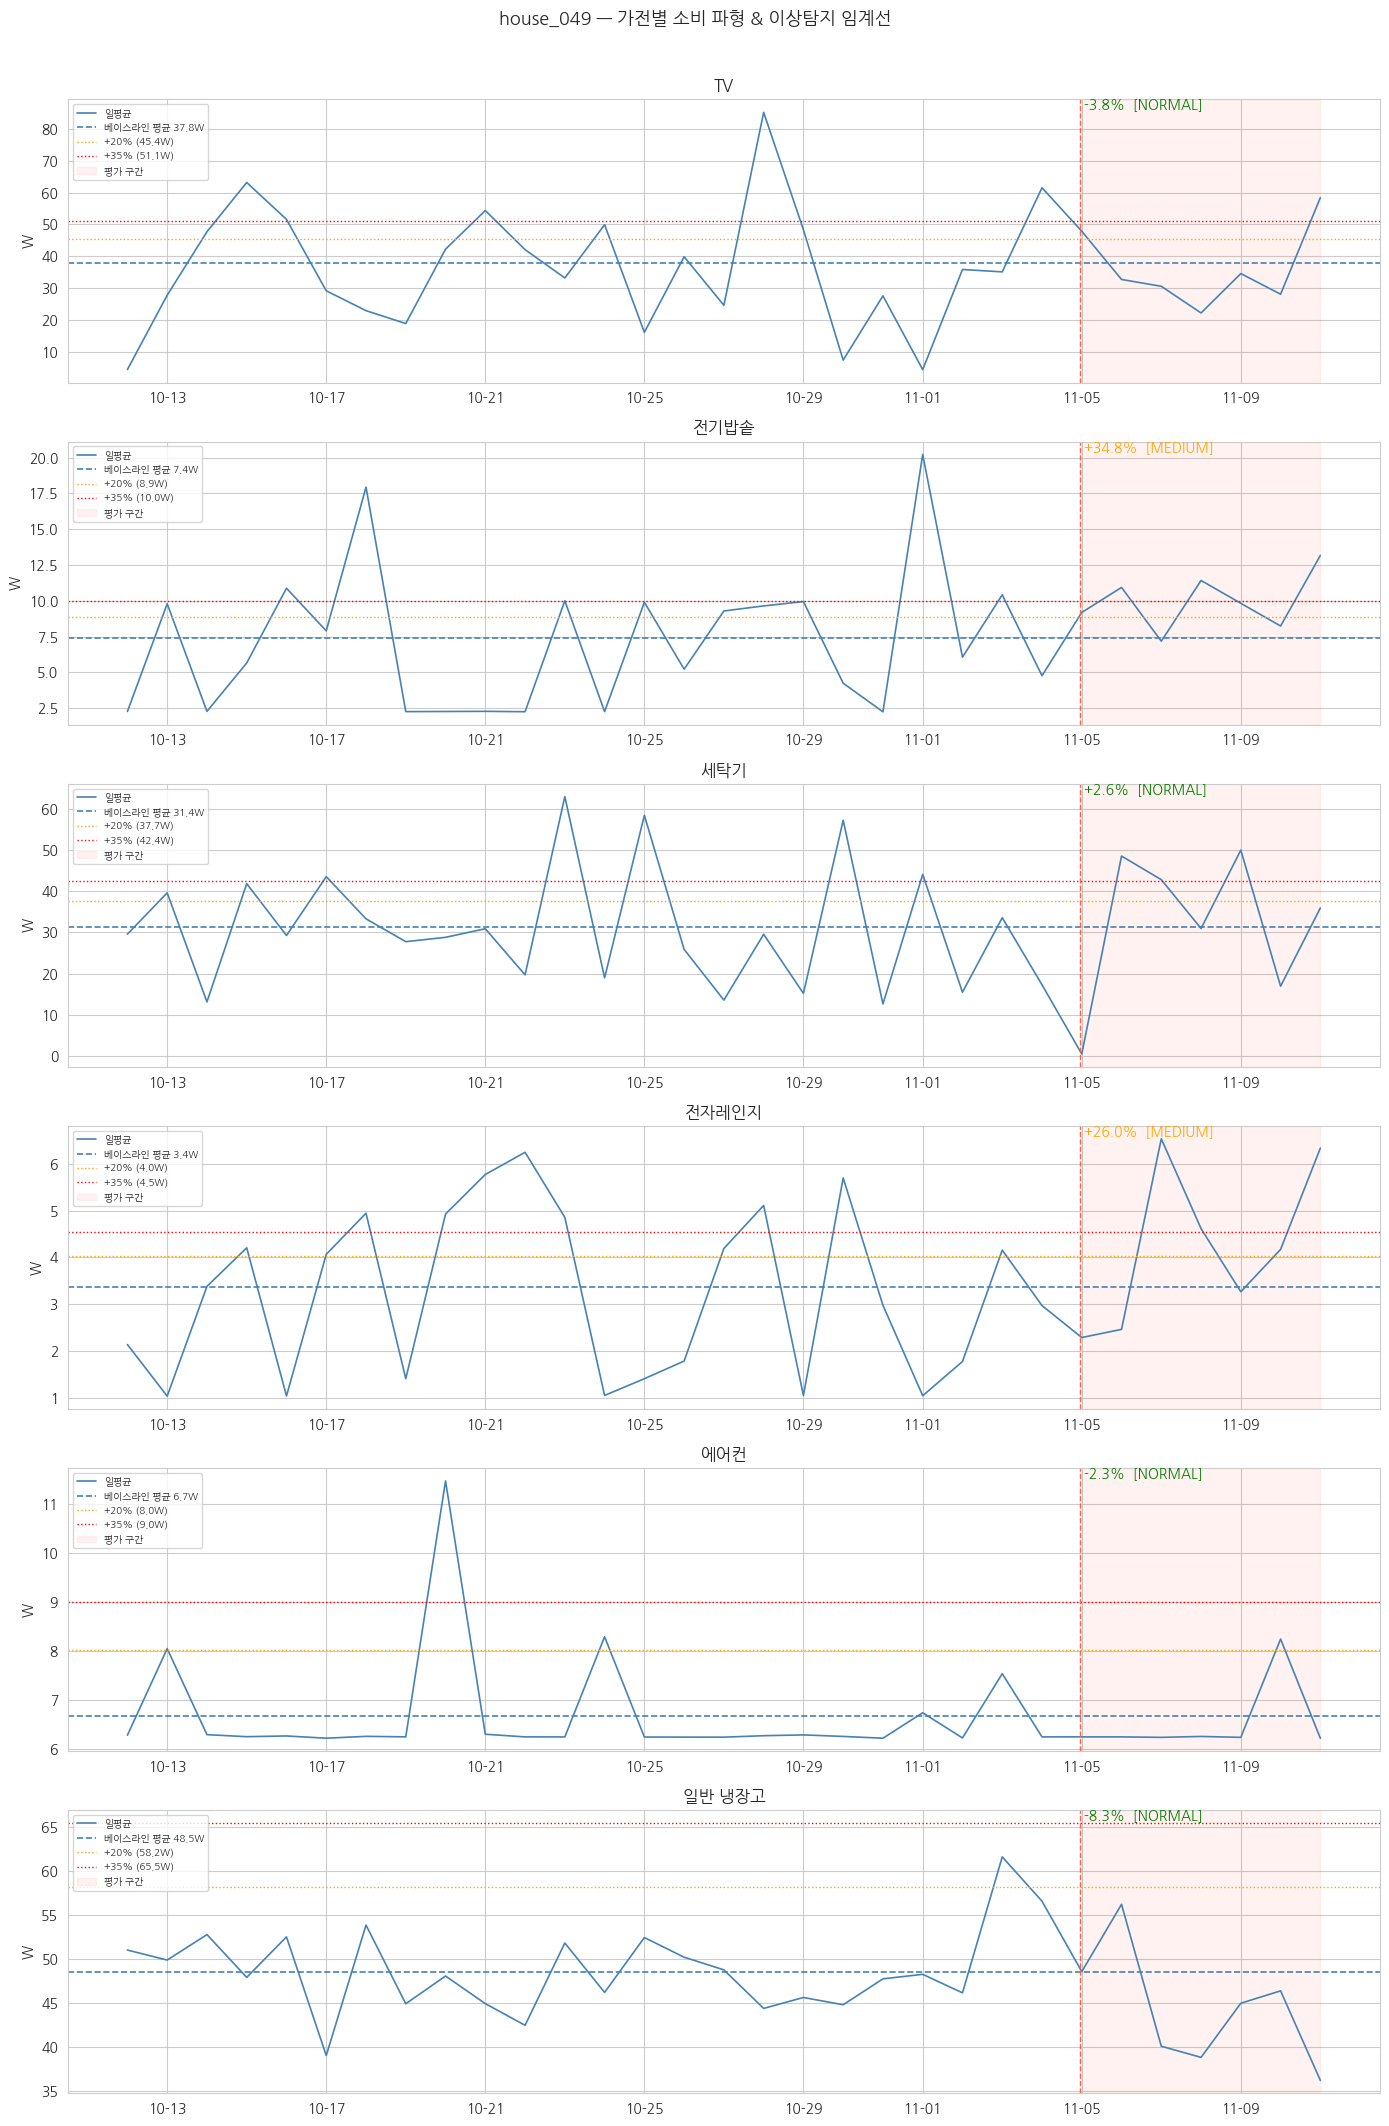

In [19]:
# 가전별 일평균 파형 + 베이스라인/평가 구간 + 변화율 표시
end_ts     = wide.index.max()
eval_start = end_ts - timedelta(weeks=1)
base_start = end_ts - timedelta(weeks=4)

MEDIUM_THR = 0.20   # +20%
HIGH_THR   = 0.35   # +35%

n = len(APPLIANCES)
fig, axes = plt.subplots(n, 1, figsize=(14, 3.5 * n), sharex=False)
if n == 1:
    axes = [axes]

for ax, name in zip(axes, APPLIANCES):
    daily = wide[name].resample('D').mean().dropna()
    bl = daily[(daily.index >= base_start) & (daily.index < eval_start)]
    ev = daily[daily.index >= eval_start]

    # 파형
    ax.plot(daily.index, daily.values, color='steelblue', linewidth=1.2, label='일평균')

    # 베이스라인 평균선
    if not bl.empty:
        bm = bl.mean()
        ax.axhline(bm, color='steelblue', linestyle='--', linewidth=1.2,
                   label=f'베이스라인 평균 {bm:.1f}W')
        # MEDIUM / HIGH 임계선
        ax.axhline(bm * (1 + MEDIUM_THR), color='orange', linestyle=':', linewidth=1,
                   label=f'+{int(MEDIUM_THR*100)}% ({bm*(1+MEDIUM_THR):.1f}W)')
        ax.axhline(bm * (1 + HIGH_THR),   color='red',    linestyle=':', linewidth=1,
                   label=f'+{int(HIGH_THR*100)}% ({bm*(1+HIGH_THR):.1f}W)')

    # 평가 구간 음영
    ax.axvspan(eval_start, daily.index.max(), alpha=0.08, color='tomato', label='평가 구간')
    ax.axvline(eval_start, color='tomato', linestyle='--', linewidth=1)

    # 변화율 텍스트
    if not bl.empty and not ev.empty:
        em = ev.mean()
        ratio = (em - bm) / bm if bm > 0 else 0
        color = 'red' if ratio >= HIGH_THR else 'orange' if ratio >= MEDIUM_THR else 'green'
        label_txt = 'HIGH' if ratio >= HIGH_THR else 'MEDIUM' if ratio >= MEDIUM_THR else 'NORMAL'
        ax.text(eval_start, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else bm * 1.5,
                f' {ratio*100:+.1f}%  [{label_txt}]',
                color=color, fontsize=10, fontweight='bold', va='top')

    ax.set_title(name)
    ax.set_ylabel('W')
    ax.legend(fontsize=7, loc='upper left')
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%m-%d'))

plt.suptitle(f'{HOUSE} — 가전별 소비 파형 & 이상탐지 임계선', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'{HOUSE}_waveform.png', dpi=120, bbox_inches='tight')
plt.show()

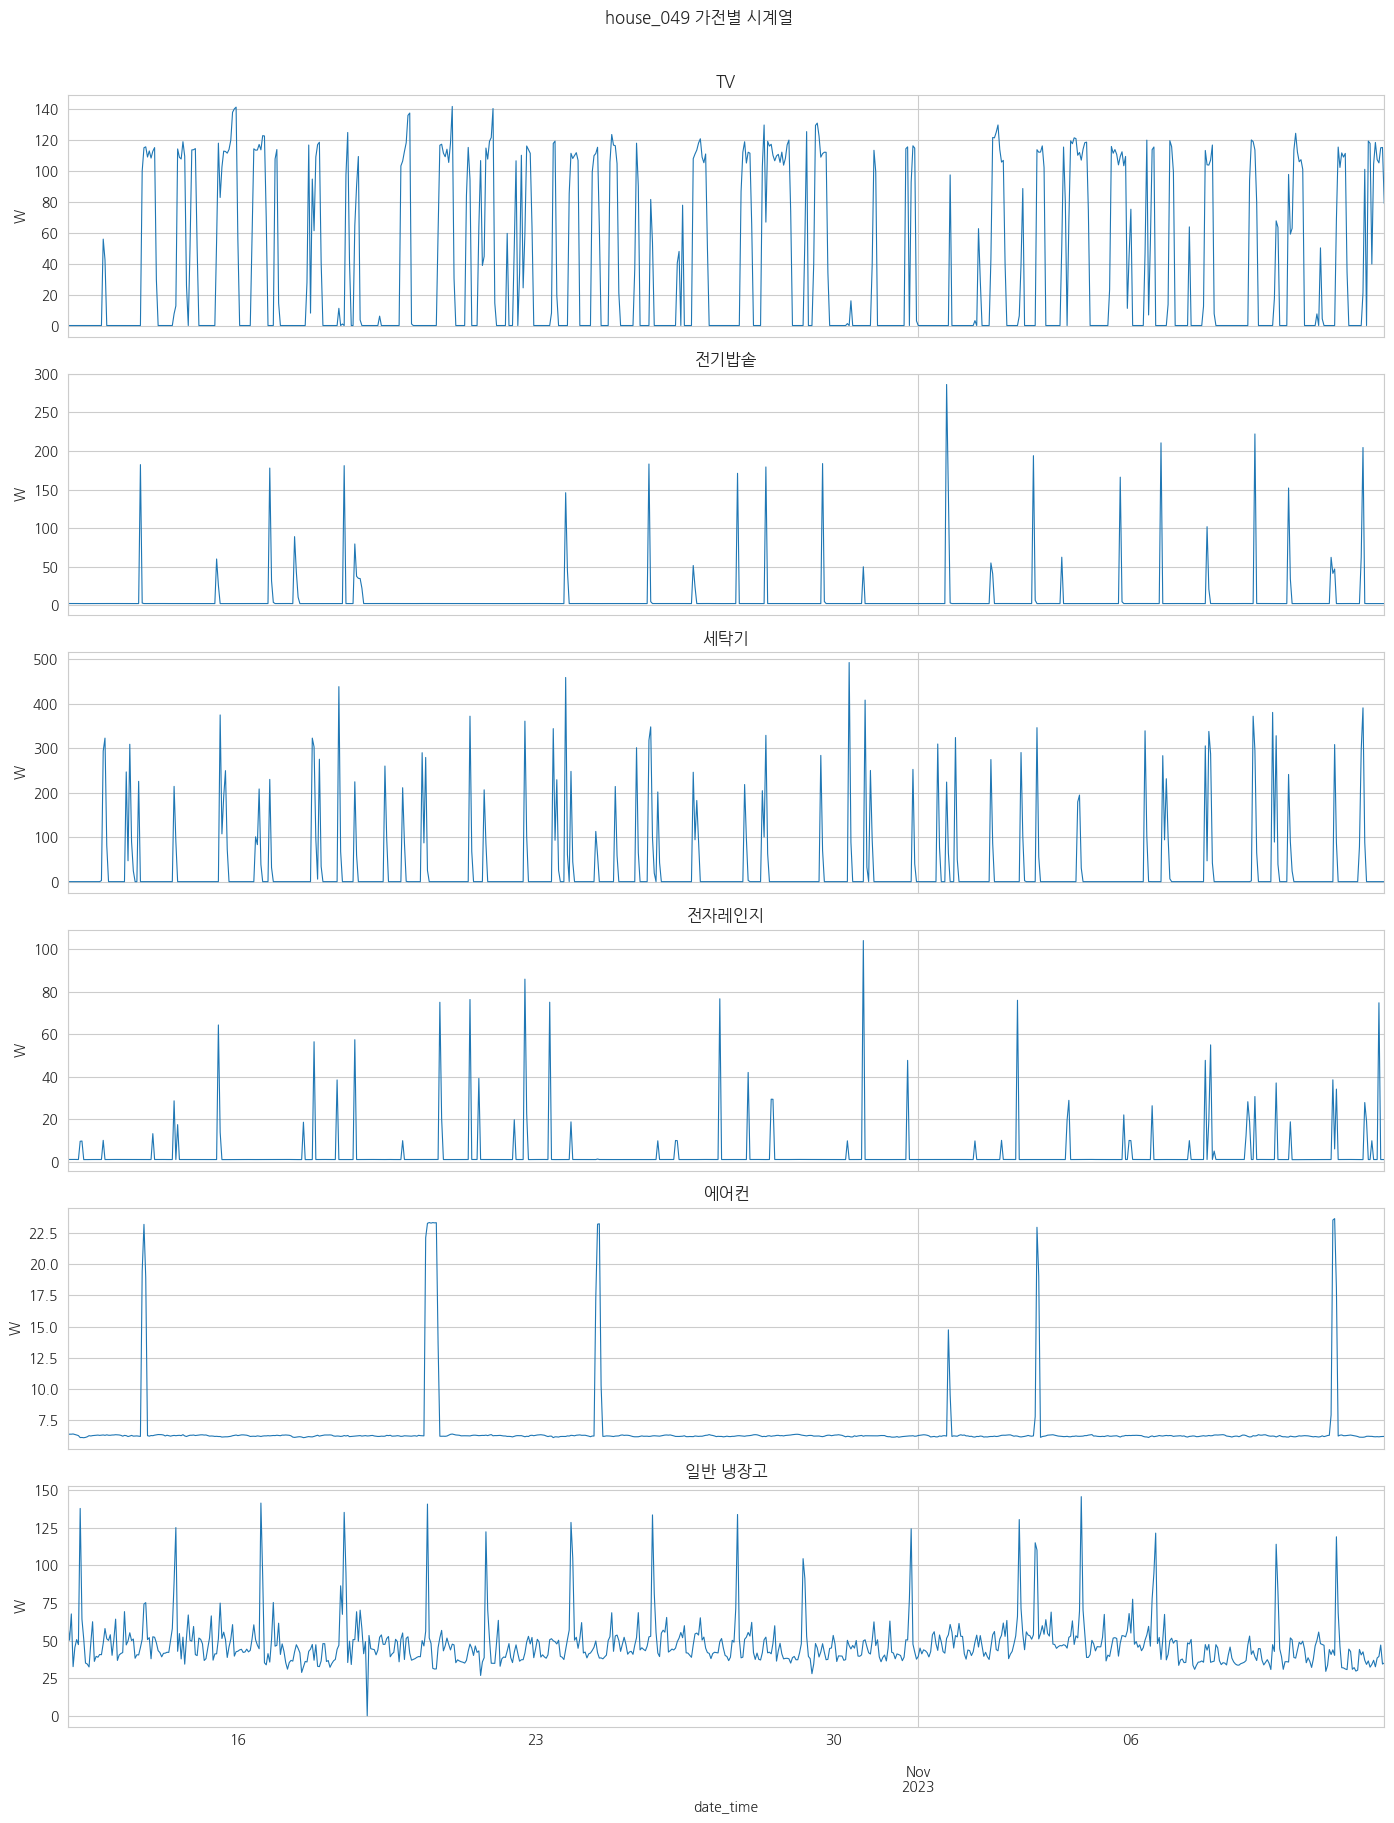

In [20]:
# 가전별 시계열 (최대 6개)
cols_to_plot = APPLIANCES[:6]
n = len(cols_to_plot)
fig, axes = plt.subplots(n, 1, figsize=(14, 3 * n), sharex=True)
if n == 1:
    axes = [axes]

for ax, name in zip(axes, cols_to_plot):
    wide[name].plot(ax=ax, linewidth=0.8)
    ax.set_title(name)
    ax.set_ylabel('W')

plt.suptitle(f'{HOUSE} 가전별 시계열', y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'{HOUSE}_timeseries.png', dpi=120)
plt.show()

## 4. 베이스라인 / 평가 구간 분리

> PoC: **마지막 1주 = 평가** / **그 앞 3주 = 베이스라인**

In [21]:
end_ts       = wide.index.max()
eval_start   = end_ts - timedelta(weeks=1)
base_start   = end_ts - timedelta(weeks=4)  # poc_mode: 앞 3주

baseline_df  = wide[(wide.index >= base_start) & (wide.index < eval_start)]
eval_df      = wide[wide.index >= eval_start]

print(f'베이스라인: {baseline_df.index.min().date()} ~ {baseline_df.index.max().date()}  ({len(baseline_df)}행)')
print(f'평가 구간:  {eval_df.index.min().date()} ~ {eval_df.index.max().date()}  ({len(eval_df)}행)')

베이스라인: 2023-10-14 ~ 2023-11-04  (504행)
평가 구간:  2023-11-04 ~ 2023-11-11  (169행)


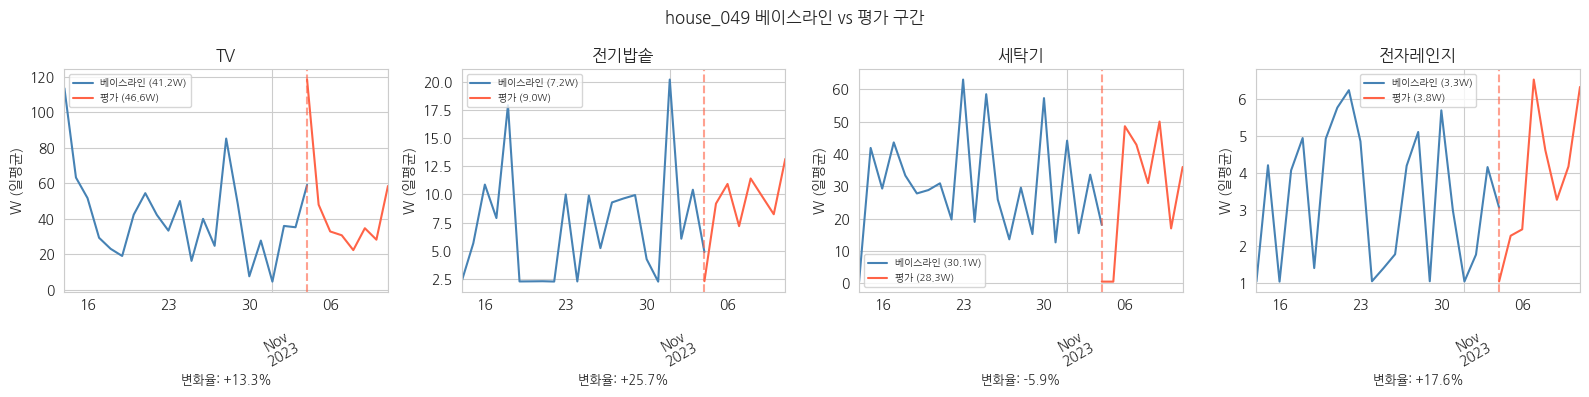

In [22]:
# 가전별 베이스라인 vs 평가 구간 시각화 (최대 4개)
cols_to_show = APPLIANCES[:4]
n = len(cols_to_show)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
if n == 1:
    axes = [axes]

for ax, name in zip(axes, cols_to_show):
    bl_daily = baseline_df[name].resample('D').mean()
    ev_daily = eval_df[name].resample('D').mean()
    bm, em = bl_daily.mean(), ev_daily.mean()

    bl_daily.plot(ax=ax, color='steelblue', label=f'베이스라인 ({bm:.1f}W)')
    ev_daily.plot(ax=ax, color='tomato', label=f'평가 ({em:.1f}W)')
    ax.axvline(eval_start, color='tomato', linestyle='--', alpha=0.6)
    ax.set_title(name)
    ax.set_ylabel('W (일평균)')
    ax.legend(fontsize=7)
    ax.tick_params(axis='x', rotation=30)
    if bm > 0:
        r = (em - bm) / bm
        ax.set_xlabel(f'변화율: {r*100:+.1f}%', fontsize=9)

plt.suptitle(f'{HOUSE} 베이스라인 vs 평가 구간')
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'{HOUSE}_split_compare.png', dpi=120)
plt.show()

## 5. 임계값 Sensitivity 분석

In [23]:
rows = []
for name in APPLIANCES:
    bl = baseline_df[name].dropna()
    ev = eval_df[name].dropna()
    if bl.mean() <= 0:
        continue
    r_mean = (ev.mean() - bl.mean()) / bl.mean()
    r_peak = (ev.max() - bl.max()) / bl.max() if bl.max() > 0 else 0
    bl_on  = (bl >= 10).sum() / max((bl.index.max() - bl.index.min()).days, 1)
    ev_on  = (ev >= 10).sum() / max((ev.index.max() - ev.index.min()).days, 1)
    r_rt   = (ev_on - bl_on) / bl_on if bl_on > 0 else 0
    rows.append({
        '가전': name,
        '베이스라인_평균W': round(bl.mean(), 1),
        '평가_평균W':       round(ev.mean(), 1),
        '소비변화%':        round(r_mean * 100, 1),
        '피크변화%':        round(r_peak * 100, 1),
        '작동시간변화%':    round(r_rt * 100, 1),
    })

result_df = pd.DataFrame(rows)
print(result_df.to_string(index=False))

    가전  베이스라인_평균W    평가_평균W     소비변화%  피크변화%  작동시간변화%
    TV  37.799999 36.900002 -2.500000  -12.2     -0.9
  전기밥솥   7.400000 10.000000 34.200001  -22.4     22.4
   세탁기  31.400000 32.099998  2.000000  -20.7    -13.3
 전자레인지   3.400000  4.200000 25.400000  -28.1     94.3
   에어컨   6.700000  6.500000 -2.300000    1.4    -42.9
일반 냉장고  48.599998 44.500000 -8.500000  -16.6     -4.0


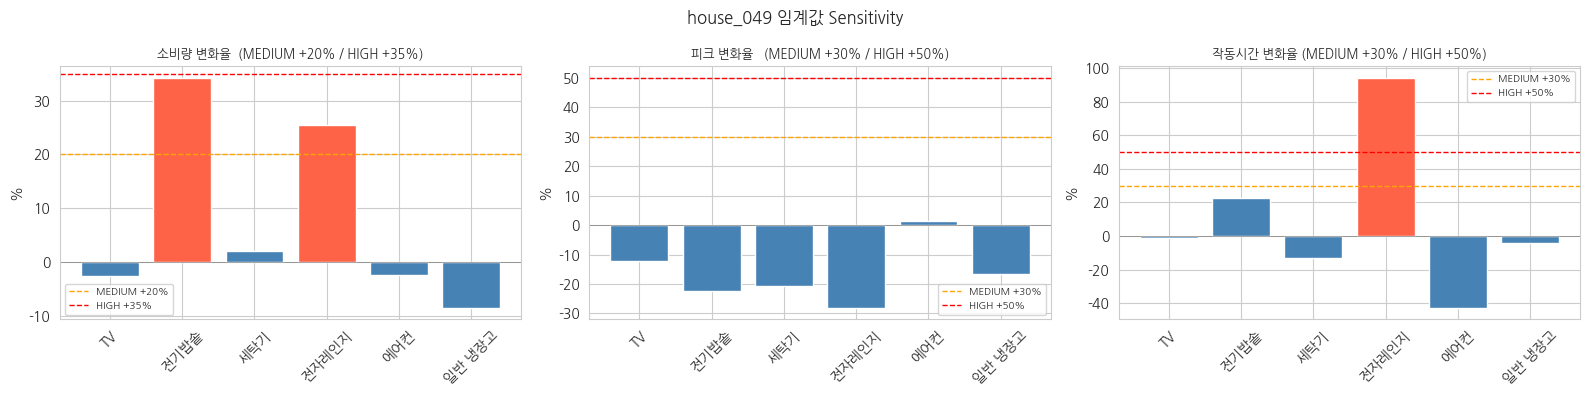

In [24]:
if not result_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for ax, col, med, high, title in [
        (axes[0], '소비변화%',     20, 35, '소비량 변화율  (MEDIUM +20% / HIGH +35%)'),
        (axes[1], '피크변화%',     30, 50, '피크 변화율   (MEDIUM +30% / HIGH +50%)'),
        (axes[2], '작동시간변화%', 30, 50, '작동시간 변화율 (MEDIUM +30% / HIGH +50%)'),
    ]:
        colors = ['tomato' if v >= med else 'steelblue' for v in result_df[col]]
        axes_bar = ax.bar(result_df['가전'], result_df[col], color=colors)
        ax.axhline(med,  color='orange', linestyle='--', linewidth=1, label=f'MEDIUM +{med}%')
        ax.axhline(high, color='red',    linestyle='--', linewidth=1, label=f'HIGH +{high}%')
        ax.axhline(0,    color='gray',   linestyle='-',  linewidth=0.5)
        ax.set_title(title, fontsize=9)
        ax.set_ylabel('%')
        ax.legend(fontsize=7)
        ax.tick_params(axis='x', rotation=45)

    plt.suptitle(f'{HOUSE} 임계값 Sensitivity')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'{HOUSE}_threshold_sensitivity.png', dpi=120)
    plt.show()

## 6. 통계 탐지기 실행 (ANOM-001)

In [25]:
# schemas.py 인라인 (모듈 import 실패 대비)
try:
    from src.models.schemas import Severity, AnomalyType, DisaggregationResult, AnomalyEvent
    print('모듈 import 성공')
except ImportError:
    class Severity(Enum):
        HIGH = 'HIGH'; MEDIUM = 'MEDIUM'; LOW = 'LOW'
    class AnomalyType(Enum):
        CONSUMPTION_INCREASE = 'CONSUMPTION_INCREASE'
        ABNORMAL_RUNTIME     = 'ABNORMAL_RUNTIME'
        PERIODICITY_CHANGE   = 'PERIODICITY_CHANGE'
        PEAK_INCREASE        = 'PEAK_INCREASE'
    @dataclass
    class DisaggregationResult:
        appliance_type: str; timestamp: datetime
        power_w: float; confidence: float; is_on: bool = False
    @dataclass
    class AnomalyEvent:
        appliance_type: str; anomaly_type: AnomalyType
        severity: Severity; detected_at: datetime
        description: str; recommended_action: str
        event_id: str = field(default_factory=lambda: str(uuid.uuid4()))
    print('인라인 스키마 사용')

인라인 스키마 사용


In [26]:
def df_to_records(df: pd.DataFrame, on_threshold_w: float = 10.0) -> list:
    """wide DataFrame → DisaggregationResult 리스트 변환."""
    records = []
    for name in df.columns:
        for ts, val in df[name].dropna().items():
            records.append(DisaggregationResult(
                appliance_type=name,
                timestamp=ts.to_pydatetime(),
                power_w=float(val),
                confidence=0.85,
                is_on=float(val) >= on_threshold_w,
            ))
    return records

all_records = df_to_records(wide)
print(f'총 레코드: {len(all_records):,}')

총 레코드: 4,464


In [27]:
class StatisticalAnomalyDetector:
    def __init__(self, thresholds=None, min_confidence=0.60, poc_mode=True):
        self.thresholds = thresholds or {
            AnomalyType.CONSUMPTION_INCREASE: (0.20, 0.35),
            AnomalyType.PEAK_INCREASE:        (0.30, 0.50),
            AnomalyType.ABNORMAL_RUNTIME:     (0.30, 0.50),
        }
        self.min_confidence = min_confidence
        self.poc_mode = poc_mode

    def detect(self, records):
        df = self._to_df(records)
        events = []
        for appliance, group in df.groupby('appliance_type'):
            filt = group[group['confidence'] >= self.min_confidence]
            if filt.empty: continue
            events += self._check(appliance, filt, 'consumption')
            events += self._check(appliance, filt, 'peak')
            events += self._check(appliance, filt, 'runtime')
        return events

    def _to_df(self, records):
        df = pd.DataFrame([{'appliance_type': r.appliance_type, 'timestamp': r.timestamp,
                            'power_w': r.power_w, 'confidence': r.confidence, 'is_on': r.is_on}
                           for r in records])
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        return df.set_index('timestamp').sort_index()

    def _split(self, group):
        now = group.index.max()
        eval_s = now - timedelta(weeks=1)
        base_s = now - timedelta(weeks=4) if self.poc_mode else now - timedelta(weeks=13)
        bl = group[(group.index >= base_s) & (group.index < eval_s)]
        ev = group[group.index >= eval_s]
        return (None, None) if bl.empty or ev.empty else (bl, ev)

    def _severity(self, ratio, atype):
        med, high = self.thresholds.get(atype, (0.20, 0.40))
        return Severity.HIGH if ratio >= high else Severity.MEDIUM if ratio >= med else None

    def _check(self, appliance, group, mode):
        bl, ev = self._split(group)
        if bl is None: return []

        if mode == 'consumption':
            bv = bl['power_w'].resample('D').mean().mean()
            ev_v = ev['power_w'].resample('D').mean().mean()
            atype = AnomalyType.CONSUMPTION_INCREASE
            desc  = lambda r: f'{appliance} 소비량 기준 대비 {r*100:+.1f}%'
        elif mode == 'peak':
            bv = bl['power_w'].max()
            ev_v = ev['power_w'].max()
            atype = AnomalyType.PEAK_INCREASE
            desc  = lambda r: f'{appliance} 최대전력 기준 대비 {r*100:+.1f}%'
        else:  # runtime
            def daily_rt(df):
                days = max((df.index.max() - df.index.min()).days, 1)
                return df['is_on'].sum() / days
            bv = daily_rt(bl); ev_v = daily_rt(ev)
            atype = AnomalyType.ABNORMAL_RUNTIME
            desc  = lambda r: f'{appliance} 작동시간 기준 대비 {r*100:+.1f}%'

        if bv <= 0: return []
        ratio = (ev_v - bv) / bv
        sev = self._severity(ratio, atype)
        if sev is None: return []
        return [AnomalyEvent(appliance_type=appliance, anomaly_type=atype, severity=sev,
                             detected_at=datetime.now(), description=desc(ratio),
                             recommended_action='기기 점검 권장')]


stat_det = StatisticalAnomalyDetector(poc_mode=True)
stat_events = stat_det.detect(all_records)
print(f'통계 탐지 이벤트: {len(stat_events)}건')
for e in stat_events:
    print(f'  [{e.severity.value:6s}] {e.anomaly_type.value:25s}  {e.description}')

통계 탐지 이벤트: 2건
  [MEDIUM] CONSUMPTION_INCREASE       전기밥솥 소비량 기준 대비 +25.7%
  [HIGH  ] ABNORMAL_RUNTIME           전자레인지 작동시간 기준 대비 +94.3%


## 7. 패턴 탐지기 실행 (ANOM-002 — Isolation Forest)

In [28]:
class PatternAnomalyDetector:
    def __init__(self, contamination=0.05, n_estimators=100, random_state=42,
                 periodicity_std_multiplier=2.0):
        self.contamination = contamination
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.periodicity_std_multiplier = periodicity_std_multiplier
        self._models = {}; self._baselines = {}

    def fit(self, records):
        df = self._to_df(records)
        for appliance, group in df.groupby('appliance_type'):
            feats = self._features(group)
            if len(feats) < 10: continue
            m = IsolationForest(contamination=self.contamination,
                                n_estimators=self.n_estimators,
                                random_state=self.random_state)
            m.fit(feats)
            self._models[appliance] = m
            self._baselines[appliance] = group

    def detect(self, records):
        df = self._to_df(records)
        events = []
        for appliance, group in df.groupby('appliance_type'):
            events += self._detect_if(appliance, group)
            events += self._detect_periodicity(appliance, group)
        return events

    def _to_df(self, records):
        df = pd.DataFrame([{'appliance_type': r.appliance_type, 'timestamp': r.timestamp,
                            'power_w': r.power_w, 'is_on': int(r.is_on)}
                           for r in records])
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df['hour'] = df['timestamp'].dt.hour
        df['dayofweek'] = df['timestamp'].dt.dayofweek
        return df

    def _features(self, group):
        return group[['power_w', 'is_on', 'hour', 'dayofweek']].values

    def _detect_if(self, appliance, group):
        m = self._models.get(appliance)
        if m is None: return []
        preds = m.predict(self._features(group))
        ratio = (preds == -1).mean()
        if ratio == 0: return []
        sev = Severity.HIGH if ratio > 0.3 else Severity.MEDIUM if ratio > 0.1 else Severity.LOW
        return [AnomalyEvent(appliance_type=appliance,
                             anomaly_type=AnomalyType.PERIODICITY_CHANGE,
                             severity=sev, detected_at=datetime.now(),
                             description=f'{appliance} 이상 패턴 {ratio*100:.1f}% 탐지',
                             recommended_action='비정상 작동 구간 확인')]

    def _detect_periodicity(self, appliance, group):
        bl = self._baselines.get(appliance)
        if bl is None or bl.empty: return []
        bp = bl.groupby('hour')['power_w'].mean()
        cp = group.groupby('hour')['power_w'].mean()
        common = bp.index.intersection(cp.index)
        if len(common) < 6: return []
        diff = (cp[common] - bp[common]).abs()
        thr = bp[common].std() * self.periodicity_std_multiplier
        if diff.max() <= thr: return []
        return [AnomalyEvent(appliance_type=appliance,
                             anomaly_type=AnomalyType.PERIODICITY_CHANGE,
                             severity=Severity.LOW, detected_at=datetime.now(),
                             description=f'{appliance} 시간대별 패턴이 평소와 다름',
                             recommended_action='사용 스케줄 변경 여부 확인')]


bl_records  = df_to_records(baseline_df)
ev_records  = df_to_records(eval_df)

pat_det = PatternAnomalyDetector()
pat_det.fit(bl_records)
pat_events = pat_det.detect(ev_records)

print(f'패턴 탐지 이벤트: {len(pat_events)}건')
for e in pat_events:
    print(f'  [{e.severity.value:6s}] {e.anomaly_type.value:25s}  {e.description}')

패턴 탐지 이벤트: 11건
  [LOW   ] PERIODICITY_CHANGE         TV 이상 패턴 5.3% 탐지
  [LOW   ] PERIODICITY_CHANGE         세탁기 이상 패턴 5.9% 탐지
  [LOW   ] PERIODICITY_CHANGE         세탁기 시간대별 패턴이 평소와 다름
  [LOW   ] PERIODICITY_CHANGE         에어컨 이상 패턴 3.6% 탐지
  [LOW   ] PERIODICITY_CHANGE         에어컨 시간대별 패턴이 평소와 다름
  [LOW   ] PERIODICITY_CHANGE         일반 냉장고 이상 패턴 4.7% 탐지
  [LOW   ] PERIODICITY_CHANGE         일반 냉장고 시간대별 패턴이 평소와 다름
  [LOW   ] PERIODICITY_CHANGE         전기밥솥 이상 패턴 6.5% 탐지
  [LOW   ] PERIODICITY_CHANGE         전기밥솥 시간대별 패턴이 평소와 다름
  [MEDIUM] PERIODICITY_CHANGE         전자레인지 이상 패턴 11.2% 탐지
  [LOW   ] PERIODICITY_CHANGE         전자레인지 시간대별 패턴이 평소와 다름


## 8. Isolation Forest 이상 구간 시각화

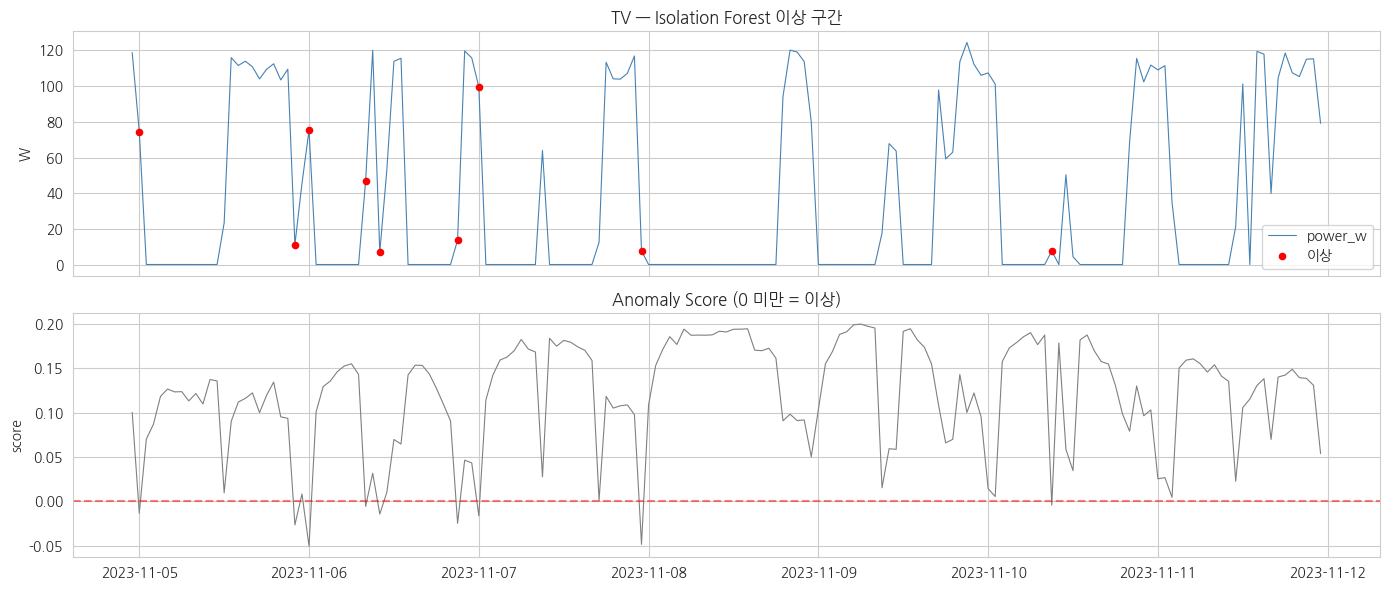

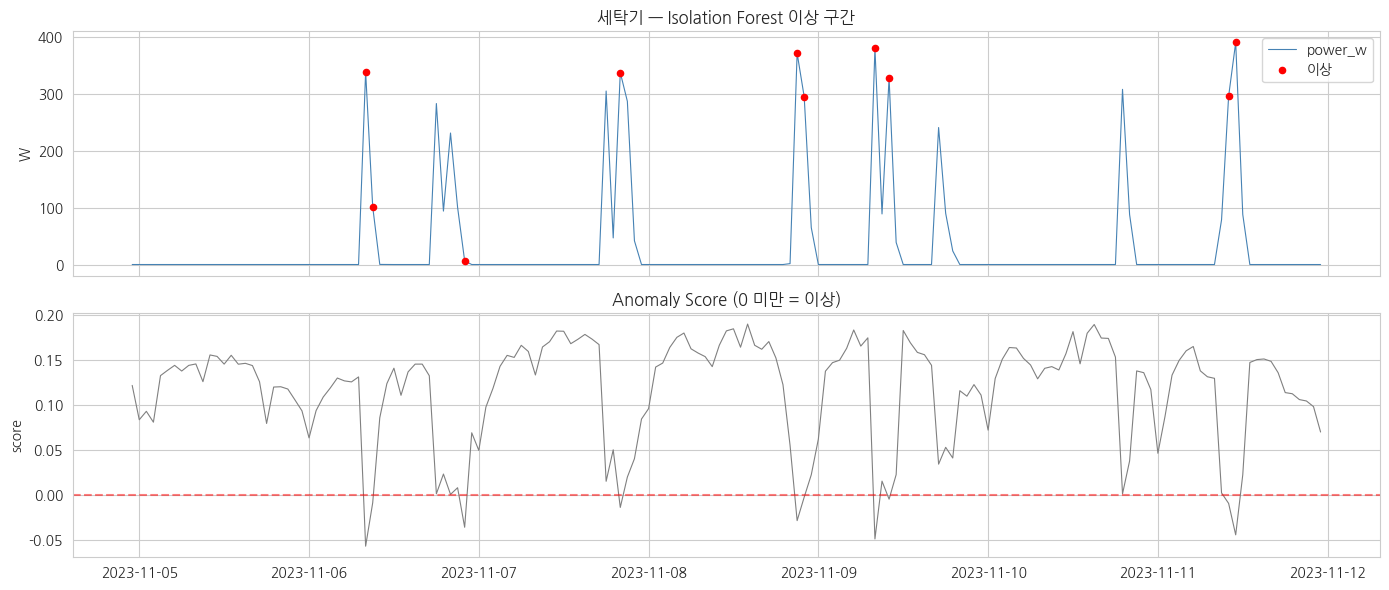

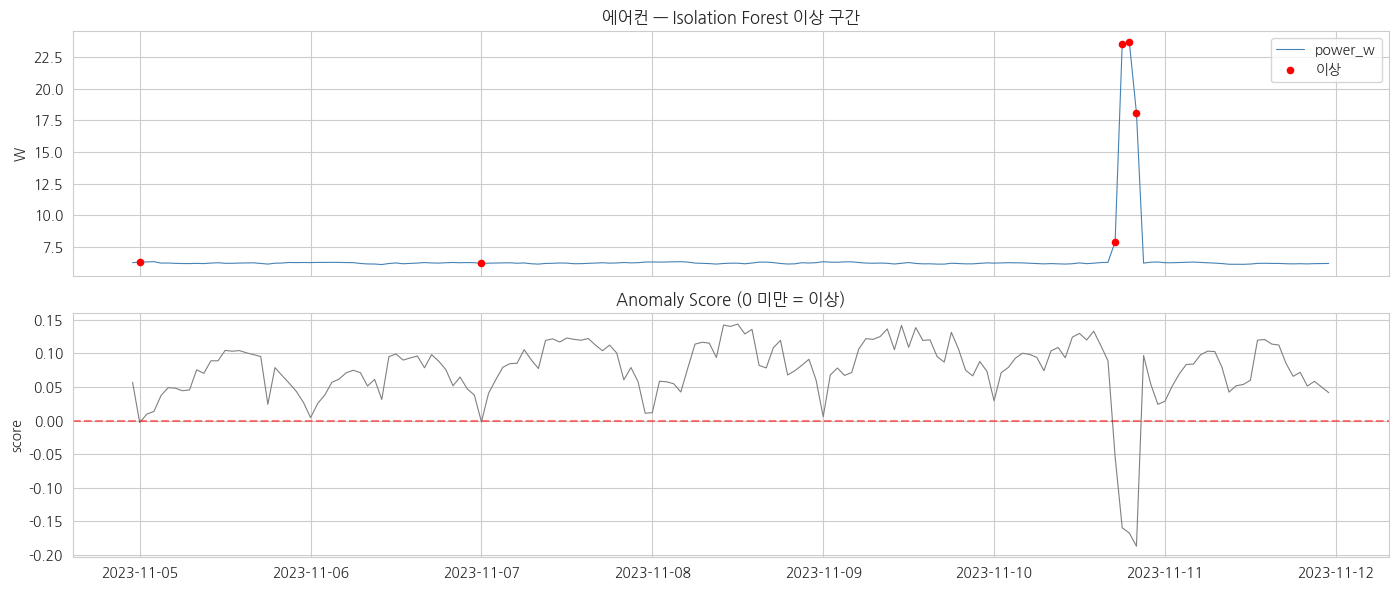

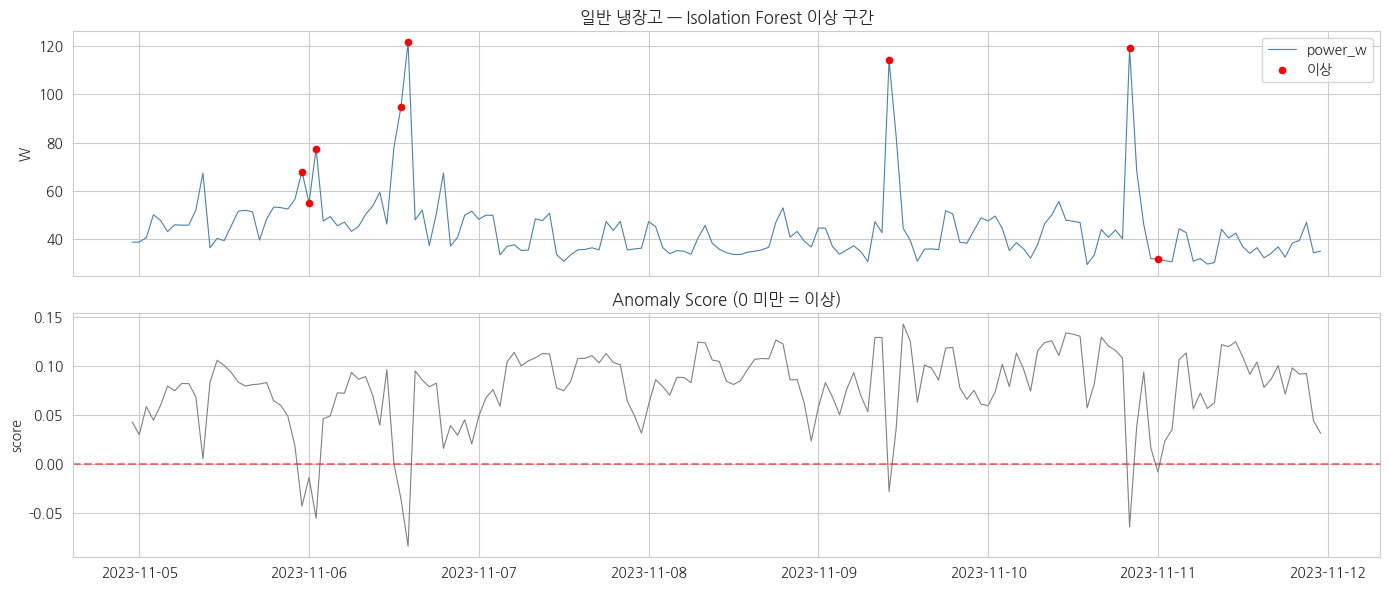

In [29]:
for appliance in list(pat_det._models.keys())[:4]:
    ev_sub = eval_df[[appliance]].dropna()
    if ev_sub.empty: continue

    feats = np.column_stack([
        ev_sub[appliance].values,
        (ev_sub[appliance] >= 10).astype(int).values,
        ev_sub.index.hour,
        ev_sub.index.dayofweek,
    ])
    preds  = pat_det._models[appliance].predict(feats)
    scores = pat_det._models[appliance].decision_function(feats)

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

    axes[0].plot(ev_sub.index, ev_sub[appliance], linewidth=0.8, color='steelblue', label='power_w')
    anom_idx = ev_sub.index[preds == -1]
    axes[0].scatter(anom_idx, ev_sub[appliance][preds == -1],
                    color='red', s=20, zorder=5, label='이상')
    axes[0].set_title(f'{appliance} — Isolation Forest 이상 구간')
    axes[0].set_ylabel('W'); axes[0].legend()

    axes[1].plot(ev_sub.index, scores, color='gray', linewidth=0.8)
    axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
    axes[1].set_title('Anomaly Score (0 미만 = 이상)')
    axes[1].set_ylabel('score')

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'{HOUSE}_{appliance}_IF.png', dpi=120)
    plt.show()

## 9. 시간대별 패턴 비교 (베이스라인 vs 평가)

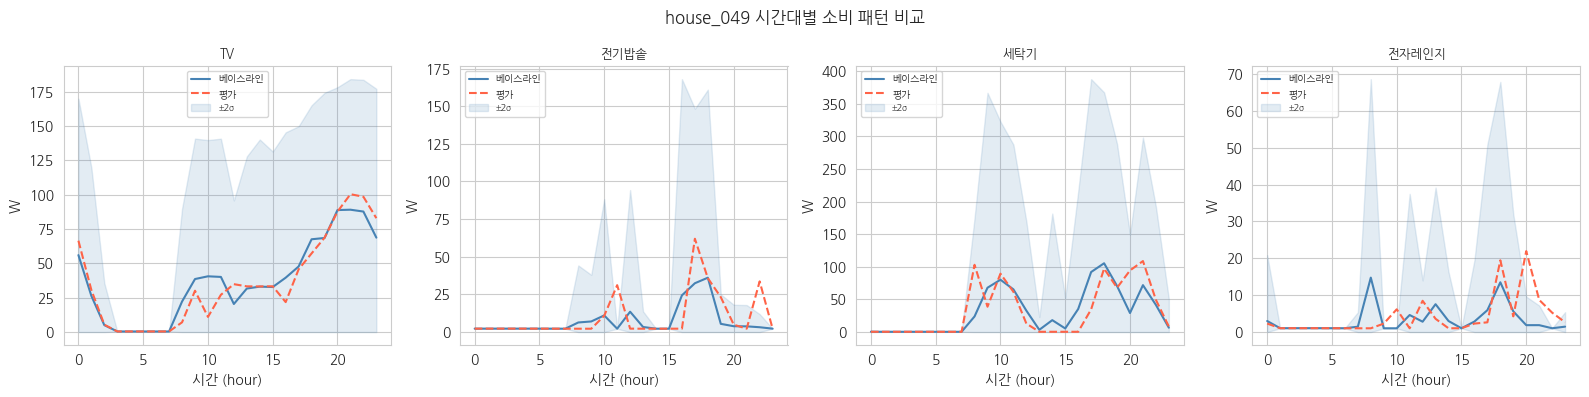

In [30]:
cols_to_show = APPLIANCES[:4]
n = len(cols_to_show)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
if n == 1: axes = [axes]

for ax, name in zip(axes, cols_to_show):
    bl_h = baseline_df[name].groupby(baseline_df.index.hour).mean()
    ev_h = eval_df[name].groupby(eval_df.index.hour).mean()
    std_bl = baseline_df[name].groupby(baseline_df.index.hour).std()

    ax.plot(bl_h.index, bl_h.values, color='steelblue', label='베이스라인')
    ax.plot(ev_h.index, ev_h.values, color='tomato', linestyle='--', label='평가')
    ax.fill_between(bl_h.index,
                    (bl_h - std_bl * 2).clip(lower=0),
                    bl_h + std_bl * 2,
                    alpha=0.15, color='steelblue', label='±2σ')
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('시간 (hour)')
    ax.set_ylabel('W')
    ax.legend(fontsize=7)

plt.suptitle(f'{HOUSE} 시간대별 소비 패턴 비교')
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'{HOUSE}_hourly_pattern.png', dpi=120)
plt.show()

## 10. 종합 결과

In [31]:
all_events = stat_events + pat_events

if all_events:
    summary_df = pd.DataFrame([{
        '가전':   e.appliance_type,
        '유형':   e.anomaly_type.value,
        '심각도': e.severity.value,
        '내용':   e.description,
    } for e in all_events])
    print(f'총 이벤트: {len(summary_df)}건')
    print(summary_df.groupby(['심각도', '유형']).size().reset_index(name='건수').to_string(index=False))
    print()
    print(summary_df[['가전', '심각도', '내용']].to_string(index=False))
    summary_df.to_csv(RESULTS_DIR / f'{HOUSE}_events.csv', index=False, encoding='utf-8-sig')
    print(f'\n저장: {RESULTS_DIR}/{HOUSE}_events.csv')
else:
    print('탐지된 이상 이벤트 없음 — 임계값 완화 또는 데이터 확인 필요')

총 이벤트: 13건
   심각도                   유형  건수
  HIGH     ABNORMAL_RUNTIME   1
   LOW   PERIODICITY_CHANGE  10
MEDIUM CONSUMPTION_INCREASE   1
MEDIUM   PERIODICITY_CHANGE   1

    가전    심각도                      내용
  전기밥솥 MEDIUM   전기밥솥 소비량 기준 대비 +25.7%
 전자레인지   HIGH 전자레인지 작동시간 기준 대비 +94.3%
    TV    LOW        TV 이상 패턴 5.3% 탐지
   세탁기    LOW       세탁기 이상 패턴 5.9% 탐지
   세탁기    LOW     세탁기 시간대별 패턴이 평소와 다름
   에어컨    LOW       에어컨 이상 패턴 3.6% 탐지
   에어컨    LOW     에어컨 시간대별 패턴이 평소와 다름
일반 냉장고    LOW    일반 냉장고 이상 패턴 4.7% 탐지
일반 냉장고    LOW  일반 냉장고 시간대별 패턴이 평소와 다름
  전기밥솥    LOW      전기밥솥 이상 패턴 6.5% 탐지
  전기밥솥    LOW    전기밥솥 시간대별 패턴이 평소와 다름
 전자레인지 MEDIUM    전자레인지 이상 패턴 11.2% 탐지
 전자레인지    LOW   전자레인지 시간대별 패턴이 평소와 다름

저장: /content/drive/MyDrive/nilm_anomaly_eda/house_049_events.csv


In [32]:
print(f"""
=== EDA 체크리스트 ({HOUSE}) ===

[ ] 가전 컬럼명이 APPLIANCE_INDEX와 일치하는지 확인
[ ] 소비 변화율 분포 보고 임계값(20%/35%) 조정 필요 여부 판단
[ ] Isolation Forest contamination=0.05 적합성 확인
[ ] on_threshold_w=10W 기준이 실제 가전 특성에 맞는지 확인
[ ] 다른 가구(house_011, house_049 등)로도 EDA 반복
    → HOUSE 변수만 바꾸고 전체 재실행
""")


=== EDA 체크리스트 (house_049) ===

[ ] 가전 컬럼명이 APPLIANCE_INDEX와 일치하는지 확인
[ ] 소비 변화율 분포 보고 임계값(20%/35%) 조정 필요 여부 판단
[ ] Isolation Forest contamination=0.05 적합성 확인
[ ] on_threshold_w=10W 기준이 실제 가전 특성에 맞는지 확인
[ ] 다른 가구(house_011, house_049 등)로도 EDA 반복
    → HOUSE 변수만 바꾸고 전체 재실행

